<a href="https://colab.research.google.com/github/JuCaRiCo/202602-AnaliticaDescriptivaPredictiva/blob/main/Matplotlib_Basico_Sesion15_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualización básica con Matplotlib
**Programación para Analítica Descriptiva y Predictiva** · MIAAD · UACJ

Unidad 2 · Sesión síncrona · Parte 1 de 2 · **Notebook de apoyo para la sesión**

Sigue la sesión ejecutando cada celda. En las celdas **Predicción**, anota qué esperas antes de ejecutar. En las celdas **Tu observación**, escribe lo que observas. La versión completa, con todas las explicaciones, se publica después de la sesión.

| Bloque | Contenido |
|---|---|
| 0 | Preparación del entorno |
| 1 | ¿Por qué graficar? |
| 2 | Anatomía de un gráfico |
| 3 | Gráfico de líneas: `plt.plot` |
| 4 | Histograma: `plt.hist` |
| 5 | Diagrama de caja: `plt.boxplot` |
| 6 | Gráfico de barras: `plt.bar` |
| 7 | Diagrama de dispersión: `plt.scatter` |
| 8 | Atajo desde pandas: `.plot(kind=...)` |
| 9 | Cierre: ¿qué gráfico para qué? |

---
## Bloque 0. Preparación del entorno

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Airdata se carga desde tu Google Drive (misma carpeta de la sesión de datos temporales). NYC Airbnb 2019 se carga desde GitHub.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ruta_air = '/content/drive/MyDrive/MIAAD/202602-AnaliticaDescriptivaPredictiva/DataFiles/Airdata.csv'
df_air = pd.read_csv(ruta_air)
print(df_air.describe())
print(df_air.head())
df_air['DateTime'] = pd.to_datetime(df_air['DateTime'], format='%m/%d/%Y %H:%M')
df_air.head()

       Temperature     Humidity   Wind_Speed  Wind_Direction  NO2_Location_A  \
count  8784.000000  8784.000000  8784.000000     8784.000000     8664.000000   
mean     13.110913    66.679417    11.279210      197.595605       22.047992   
std       7.363943    14.871943     8.443103       91.961627       15.597173   
min      -2.789471    20.000000     0.000000        1.218872       -0.460000   
25%       7.360529    56.000000     5.506941      116.565050       10.600000   
50%      12.680529    68.000000     8.891343      206.138925       17.550000   
75%      18.553030    78.000000    14.720416      272.503370       29.300000   
max      33.870530    98.000000    65.446770      360.000000      116.600000   

       NO2_Location_B  NO2_Location_C  
count     8204.000000     8652.000000  
mean        29.000569       45.347931  
std         20.630746       26.735531  
min          0.430000        0.150000  
25%         13.900000       24.030000  
50%         22.750000       40.550000  

,DateTime,Temperature,Humidity,Wind_Speed,Wind_Direction,NO2_Location_A,NO2_Location_B,NO2_Location_C
0,2020-01-01 00:00:00,2.180529,87,1.484318,75.963760,39.23,52.88,62.37
1,2020-01-01 01:00:00,1.490529,89,2.741678,113.198590,38.30,44.95,52.53
2,2020-01-01 02:00:00,1.690529,85,3.563818,135.000000,NaN,48.40,54.80
3,2020-01-01 03:00:00,1.430529,84,2.811690,129.805570,37.28,47.18,50.80
4,2020-01-01 04:00:00,0.840529,86,1.800000,126.869896,29.97,41.48,54.43


In [ ]:
url_bnb = 'https://raw.githubusercontent.com/ManarOmar/New-York-Airbnb-2019/master/AB_NYC_2019.csv'
df_bnb = pd.read_csv(url_bnb)
df_bnb[['neighbourhood_group', 'room_type', 'price']].head()

,neighbourhood_group,room_type,price
0,Brooklyn,Private room,149
1,Manhattan,Entire home/apt,225
2,Manhattan,Private room,150
3,Brooklyn,Entire home/apt,89
4,Manhattan,Entire home/apt,80


---
## Bloque 1. ¿Por qué graficar?

In [ ]:
df_bnb['price'].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


**Predicción.** Con solo estos números, ¿cómo imaginas la distribución del precio? ¿Simétrica? ¿Con valores extremos?

**Tu observación:** _escribe aquí lo que observas._

---
## Bloque 2. Anatomía de un gráfico

| Elemento | Qué es |
|---|---|
| **Figure** | El lienzo completo; define el tamaño |
| **Axes** | El área del gráfico: datos, ejes X y Y, título |

**Receta:** `plt.figure(figsize=...)` → dibujar (`plt.plot`, `plt.hist`, ...) → rotular (`title`, `xlabel`, `ylabel`, `legend`) → `plt.show()`

---
## Bloque 3. Gráfico de líneas: `plt.plot(x, y)`

Muestra cómo cambia una variable en una secuencia ordenada (tiempo). `x` y `y` deben tener la misma longitud.

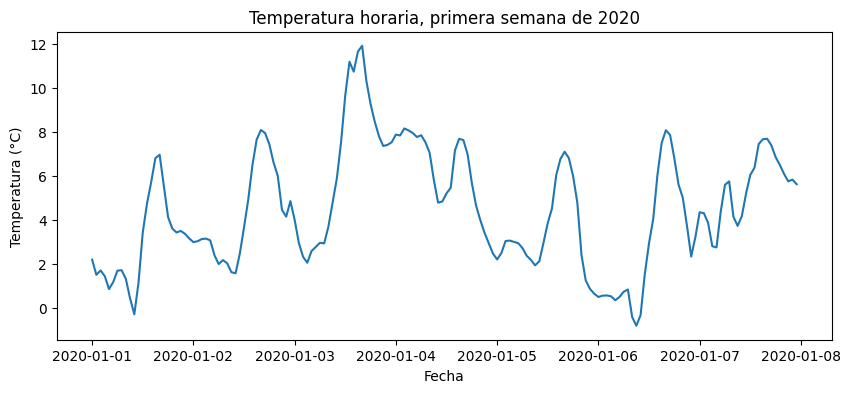

In [ ]:
semana = df_air.iloc[:168]

plt.figure(figsize=(10, 4))
plt.plot(semana['DateTime'], semana['Temperature'])
plt.title('Temperatura horaria, primera semana de 2020')
plt.xlabel('Fecha')
plt.ylabel('Temperatura (°C)')
plt.show()

### Varias series en el mismo gráfico

**Predicción.** ¿Qué estación tendrá concentraciones más altas? ¿Las dos líneas serán continuas?

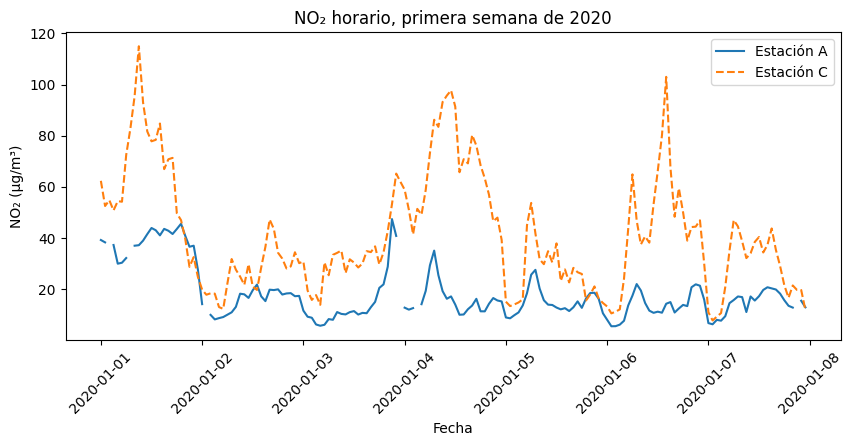

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(semana['DateTime'], semana['NO2_Location_A'], color='tab:blue', label='Estación A')
plt.plot(semana['DateTime'], semana['NO2_Location_C'], color='tab:orange', linestyle='--', label='Estación C')
plt.title('NO₂ horario, primera semana de 2020')
plt.xlabel('Fecha')
plt.ylabel('NO₂ (µg/m³)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### Error intencional 1: longitudes distintas

Supón que quieres graficar la temperatura de la semana, pero seleccionas la columna del DataFrame completo.

ValueError: x and y must have same first dimension, but have shapes (168,) and (8784,)

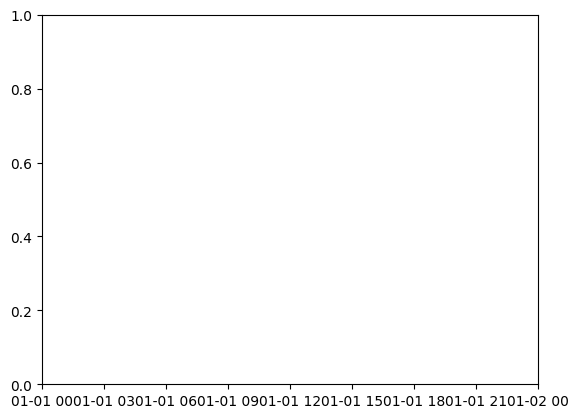

In [ ]:
plt.plot(semana['DateTime'], df_air['Temperature'])

**¿Qué dice el error y cómo lo corriges?** _escribe aquí._

---
## Bloque 4. Histograma: `plt.hist(serie, bins=n)`

Muestra la distribución de una variable numérica. `bins` = número de intervalos.

**Predicción.** ¿La temperatura horaria de 2020 tendrá una distribución simétrica?

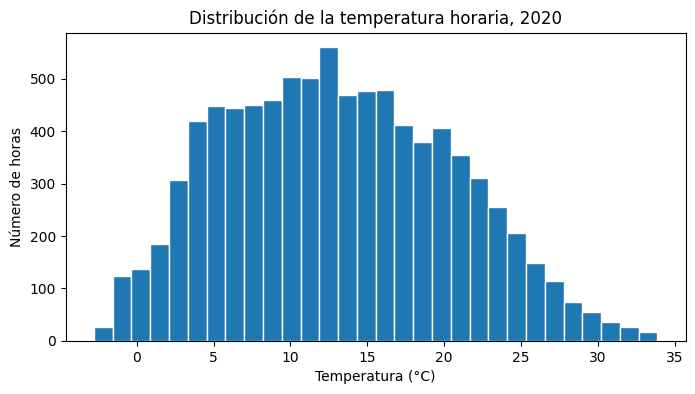

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df_air['Temperature'], bins=30, edgecolor='white')
plt.title('Distribución de la temperatura horaria, 2020')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Número de horas')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### Efecto de `bins`

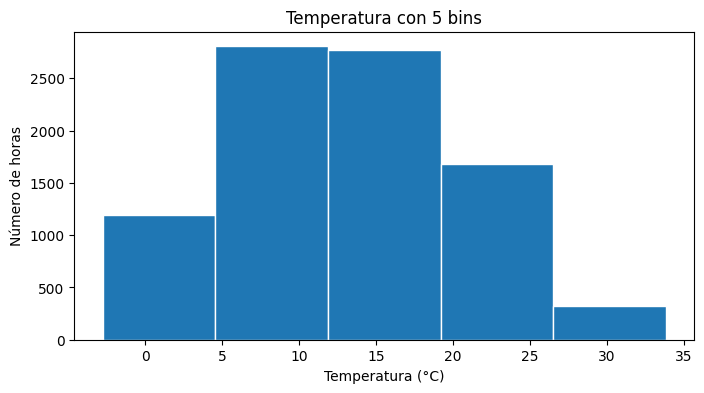

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df_air['Temperature'], bins=5, edgecolor='white')
plt.title('Temperatura con 5 bins')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Número de horas')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### Regreso al precio de Airbnb

**Predicción.** Con lo que viste en el bloque 1, ¿cómo se verá el histograma del precio?

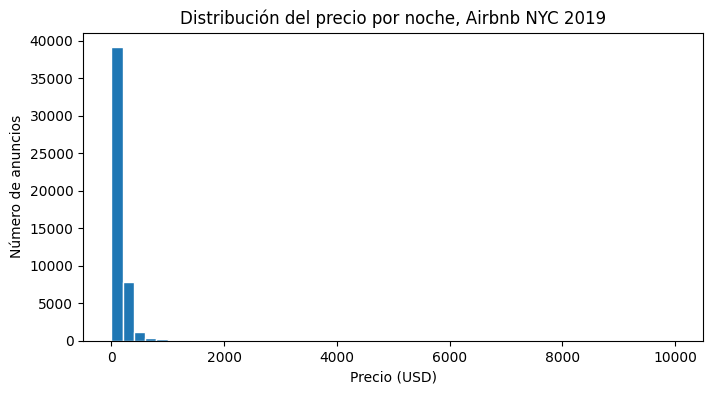

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df_bnb['price'], bins=50, edgecolor='white')
plt.title('Distribución del precio por noche, Airbnb NYC 2019')
plt.xlabel('Precio (USD)')
plt.ylabel('Número de anuncios')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

Una forma de ver la mayoría de los datos es graficar solo un rango, con una máscara booleana como las que ya usan. El 98% de los anuncios cuesta 500 o menos.

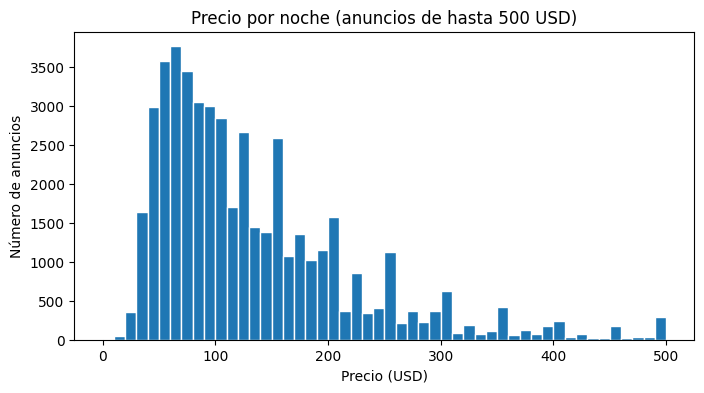

In [ ]:
precios_hasta_500 = df_bnb.loc[df_bnb['price'] <= 500, 'price']

plt.figure(figsize=(8, 4))
plt.hist(precios_hasta_500, bins=50, edgecolor='white')
plt.title('Precio por noche (anuncios de hasta 500 USD)')
plt.xlabel('Precio (USD)')
plt.ylabel('Número de anuncios')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

---
## Bloque 5. Diagrama de caja: `plt.boxplot(datos)`

| Elemento | Representa |
|---|---|
| Línea central | Mediana |
| Caja | De Q1 a Q3 (IQR) |
| Bigotes | Hasta 1.5 × IQR desde la caja |
| Puntos | Posibles atípicos |

Con una lista `[s1, s2, s3]` dibuja una caja por serie. `plt.xticks([1, 2, 3], nombres)` las rotula.

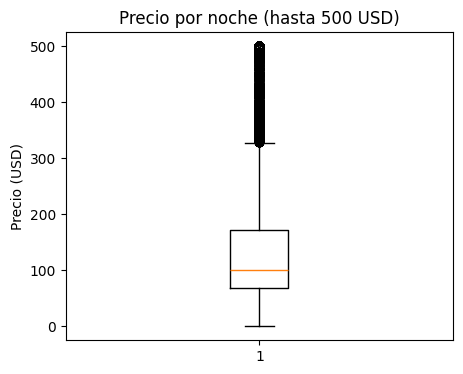

In [ ]:
plt.figure(figsize=(5, 4))
plt.boxplot(precios_hasta_500)
plt.title('Precio por noche (hasta 500 USD)')
plt.ylabel('Precio (USD)')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### Comparar grupos

**Predicción.** ¿Qué tipo de alojamiento tendrá la mediana más alta? ¿Cuál será el más disperso?

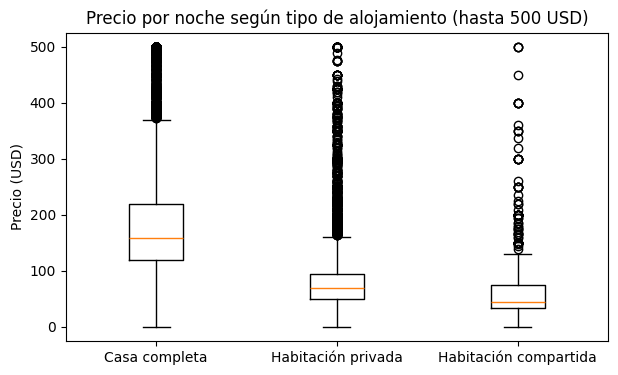

In [ ]:
bnb_500 = df_bnb[df_bnb['price'] <= 500]
casa = bnb_500.loc[bnb_500['room_type'] == 'Entire home/apt', 'price']
privada = bnb_500.loc[bnb_500['room_type'] == 'Private room', 'price']
compartida = bnb_500.loc[bnb_500['room_type'] == 'Shared room', 'price']

plt.figure(figsize=(7, 4))
plt.boxplot([casa, privada, compartida])
plt.xticks([1, 2, 3], ['Casa completa', 'Habitación privada', 'Habitación compartida'])
plt.title('Precio por noche según tipo de alojamiento (hasta 500 USD)')
plt.ylabel('Precio (USD)')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### Un resultado inesperado

**Predicción.** ¿Cómo se verá el diagrama de caja de la concentración de NO₂ en la estación B?

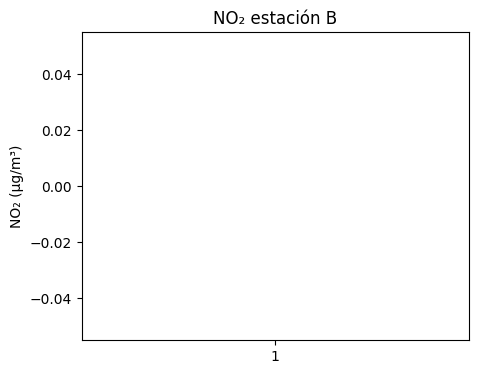

In [ ]:
plt.figure(figsize=(5, 4))
plt.boxplot(df_air['NO2_Location_B'])
plt.title('NO₂ estación B')
plt.ylabel('NO₂ (µg/m³)')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

---
## Bloque 6. Gráfico de barras: `plt.bar(categorias, alturas)`

Una cantidad por categoría. Con `value_counts()`: `conteo.index` son las categorías y `conteo.values` las alturas.

In [ ]:
conteo = df_bnb['neighbourhood_group'].value_counts()
conteo

,count
neighbourhood_group,
Manhattan,21661
Brooklyn,20104
Queens,5666
Bronx,1091
Staten Island,373


### Error intencional 2: un solo argumento

In [ ]:
plt.bar(conteo)

TypeError: bar() missing 1 required positional argument: 'height'

**¿Qué dice el error y cómo lo corriges?** _escribe aquí._

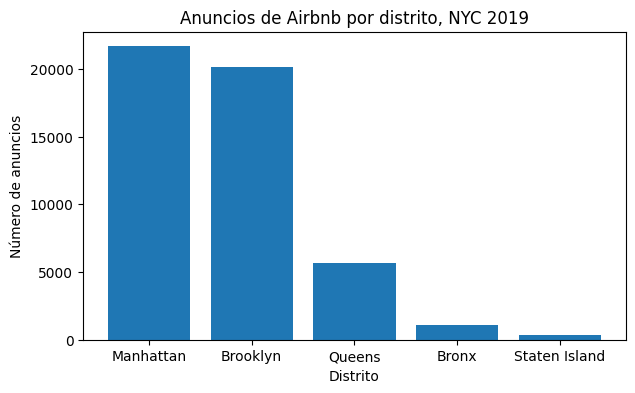

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(conteo.index, conteo.values, color='tab:blue')
plt.title('Anuncios de Airbnb por distrito, NYC 2019')
plt.xlabel('Distrito')
plt.ylabel('Número de anuncios')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### Barras horizontales: `plt.barh`

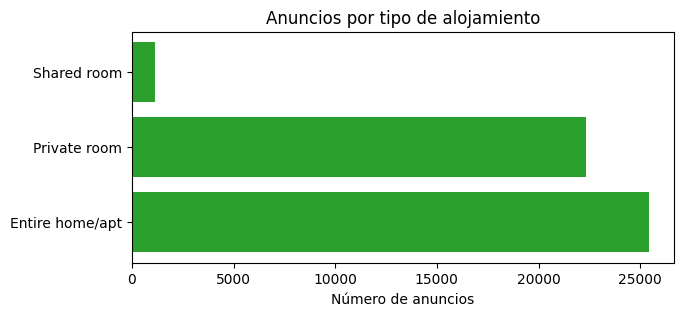

In [ ]:
tipos = df_bnb['room_type'].value_counts()

plt.figure(figsize=(7, 3))
plt.barh(tipos.index, tipos.values, color='tab:green')
plt.title('Anuncios por tipo de alojamiento')
plt.xlabel('Número de anuncios')
plt.show()

---
## Bloque 7. Diagrama de dispersión: `plt.scatter(x, y)`

Muestra la relación entre dos variables numéricas: un punto por fila, sin unir. `s` = tamaño, `alpha` = transparencia.

**Predicción.** Cuando la estación A registra un valor alto de NO₂, ¿la estación B también?

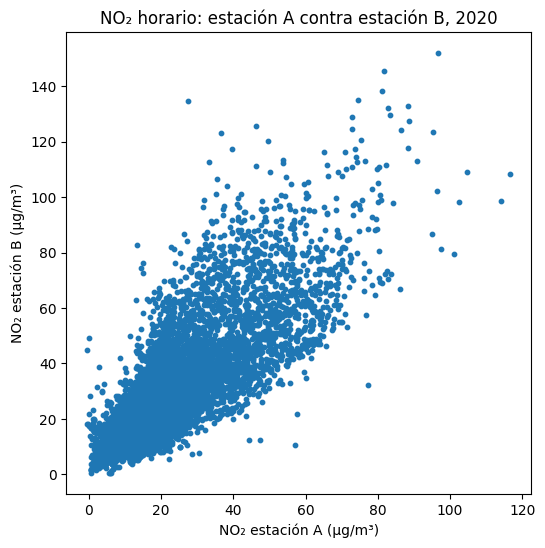

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(df_air['NO2_Location_A'], df_air['NO2_Location_B'], s=10)
plt.title('NO₂ horario: estación A contra estación B, 2020')
plt.xlabel('NO₂ estación A (µg/m³)')
plt.ylabel('NO₂ estación B (µg/m³)')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

### Transparencia para muchos puntos

**Predicción.** Con `alpha=0.2`, ¿qué zona del gráfico se verá más oscura?

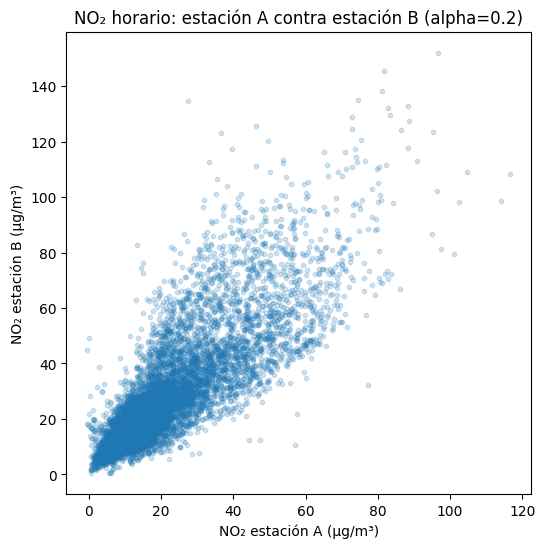

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(df_air['NO2_Location_A'], df_air['NO2_Location_B'], s=10, alpha=0.2)
plt.title('NO₂ horario: estación A contra estación B (alpha=0.2)')
plt.xlabel('NO₂ estación A (µg/m³)')
plt.ylabel('NO₂ estación B (µg/m³)')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

In [ ]:
ambas = df_air[['NO2_Location_A', 'NO2_Location_B']].dropna()
print('Horas del año:     ', len(df_air))
print('Puntos dibujados:  ', len(ambas))
print('Horas que no aparecen:', len(df_air) - len(ambas))

Horas del año:      8784
Puntos dibujados:   8089
Horas que no aparecen: 695


**Tu observación:** _escribe aquí lo que observas._

### Cuando no hay relación

**Predicción.** ¿La temperatura y la concentración de NO₂ en la estación C estarán relacionadas?

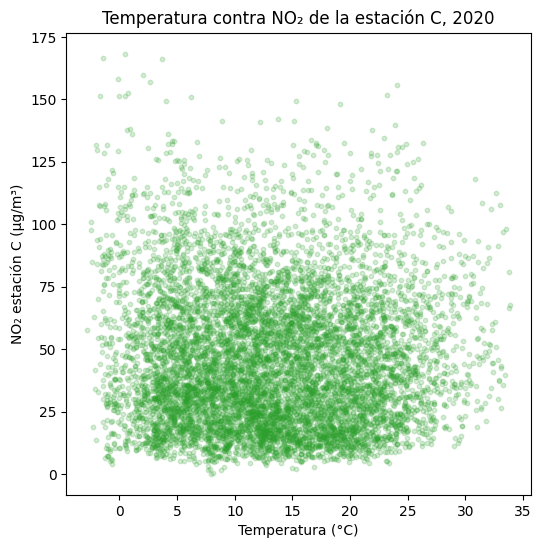

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(df_air['Temperature'], df_air['NO2_Location_C'], s=10, alpha=0.2, color='tab:green')
plt.title('Temperatura contra NO₂ de la estación C, 2020')
plt.xlabel('Temperatura (°C)')
plt.ylabel('NO₂ estación C (µg/m³)')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

---
## Bloque 8. Atajo desde pandas: `.plot(kind=...)`

`kind='line'`, `'hist'`, `'box'`, `'bar'`, `'barh'`, `'scatter'`. Llama a Matplotlib internamente.

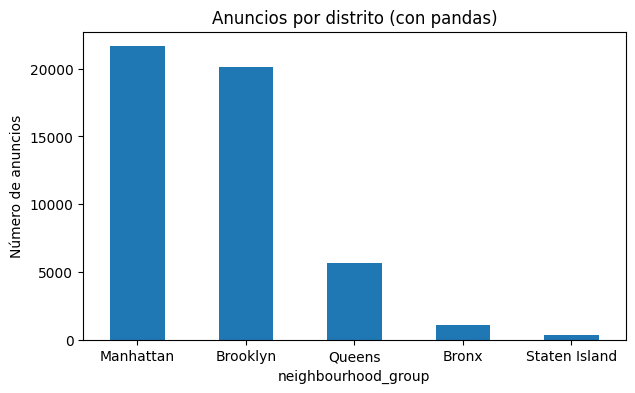

In [ ]:
plt.figure(figsize=(7, 4))
conteo.plot(kind='bar', color='tab:blue')
plt.title('Anuncios por distrito (con pandas)')
plt.ylabel('Número de anuncios')
plt.xticks(rotation=0)
plt.show()

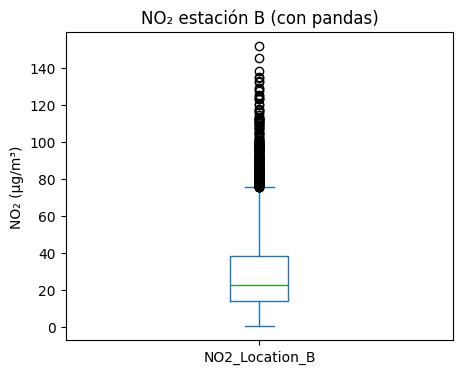

In [ ]:
plt.figure(figsize=(5, 4))
df_air['NO2_Location_B'].plot(kind='box')
plt.title('NO₂ estación B (con pandas)')
plt.ylabel('NO₂ (µg/m³)')
plt.show()

**Tu observación:** _escribe aquí lo que observas._

---
## Bloque 9. Cierre: ¿qué gráfico para qué?

| Quiero mostrar... | Gráfico | Función |
|---|---|---|
| Cambio en el tiempo | Líneas | `plt.plot` |
| Distribución de una variable | Histograma | `plt.hist` |
| Comparación de distribuciones entre grupos | Diagrama de caja | `plt.boxplot` |
| Cantidad por categoría | Barras | `plt.bar`, `plt.barh` |
| Relación entre dos variables | Dispersión | `plt.scatter` |

**Lo más importante que aprendí en esta parte:** _escribe aquí._